# Exp 4: ORDER_LINE ⋈ STOCK (HTAP Join Validation)

Compares: **SNAP, MONO-NR/RR/WR, DUAL-WR, EPOCH-NR/RR/WR** with Zipfian skewed updates.

Graph style matches Exp 3 / `tpch_q14_all_variants.ipynb` (Paul Tol Bright palette, solid=write, hatch=read).

**Run all cells top-to-bottom** — data generation, build, benchmark, and plot are all handled here.

In [109]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'matplotlib'])
print('done')

done



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [110]:
from pathlib import Path
import subprocess, os, sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

ROOT     = Path('../../').resolve()
EXP4_DIR = (ROOT / 'benches' / 'exp4_stock_join').resolve()
DATA_DIR = EXP4_DIR / 'data'
BIN      = ROOT / 'target' / 'release' / 'stock_join_bench'

DATA_DIR.mkdir(parents=True, exist_ok=True)
(EXP4_DIR / 'figs').mkdir(parents=True, exist_ok=True)

# ===== CONFIG =====
WAREHOUSES = 1         # CH-benCHmark scale factor (warehouses)
UPDATE_PCT = 10.0      # fixed update intensity for main stacked bar
DIST       = 'zipf0.99'
# DIST       = 'uniform'
ZIPF_THETA = 0.99
BUCKET_NUM = 2048
WARMUP     = 1
REPEAT     = 10
TRIM       = 2

# All series: (table_type, repair_mode)
SERIES = [
    ('naive', 'nr'),
    ('heap',  'nr'), ('heap',  'rr'), ('heap',  'wr'),
    ('chain', 'wr'),
    ('par',   'nr'), ('par',   'rr'), ('par',   'wr'),
]
# ==================

W           = WAREHOUSES
pct_label   = f'{UPDATE_PCT:g}'
STOCK_FILE  = DATA_DIR / f'stock_w{W}.tbl'
OL_FILE     = DATA_DIR / f'orderline_w{W}.tbl'
OUT_CSV     = DATA_DIR / f'exp4_w{W}_{pct_label}pct_{DIST}.csv'

print('ROOT    :', ROOT)
print('CSV     :', OUT_CSV)

ROOT    : .
CSV     : ./benches/exp4_stock_join/data/exp4_w1_10pct_zipf0.99.csv


In [111]:
# ── Build Rust binary ──────────────────────────────────────────────────────
print('Building stock_join_bench...')
result = subprocess.run(
    ['cargo', 'build', '--release', '--bin', 'stock_join_bench'],
    cwd=ROOT, capture_output=True, text=True,
)
if result.returncode != 0:
    print('STDERR:', result.stderr[-2000:])
    raise RuntimeError('cargo build failed')
print('Build OK')

Building stock_join_bench...
Build OK


In [112]:
# ── Generate CH-benCHmark data (STOCK + ORDER_LINE) if not present ─────────
# Equivalent to TPC-H dbgen in Exp 3; uses generate_chbenchmark_data.py
GEN_DATA = EXP4_DIR / 'generate_chbenchmark_data.py'

if not STOCK_FILE.exists() or not OL_FILE.exists():
    print(f'Generating CH-benCHmark tables (W={W})...')
    r = subprocess.run(
        [sys.executable, str(GEN_DATA), '--warehouses', str(W), '--output-dir', str(DATA_DIR)],
        check=True, capture_output=True, text=True,
    )
    print(r.stdout)
else:
    print(f'CH-benCHmark data exists: {STOCK_FILE.name}, {OL_FILE.name}')

stock_rows = sum(1 for _ in open(STOCK_FILE))
ol_rows    = sum(1 for _ in open(OL_FILE))
print(f'STOCK: {stock_rows:,}  ORDER_LINE: {ol_rows:,}')

CH-benCHmark data exists: stock_w1.tbl, orderline_w1.tbl
STOCK: 100,000  ORDER_LINE: 299,724


In [113]:
# ── Ensure update file exists ──────────────────────────────────────────────
# Equivalent to generate_updates.py in Exp 3; uses generate_stock_updates.py
GEN_UPD    = EXP4_DIR / 'generate_stock_updates.py'
updates_file = DATA_DIR / f'stock_updates_w{W}_{pct_label}pct_{DIST}.tbl'

if not updates_file.exists():
    print(f'Generating updates: {updates_file.name}')
    r = subprocess.run(
        [sys.executable, str(GEN_UPD),
         str(STOCK_FILE), str(UPDATE_PCT), str(W),
         '--zipf', str(ZIPF_THETA),
         '--output-dir', str(DATA_DIR)],
        check=True, capture_output=True, text=True,
    )
    print(r.stdout)
else:
    print(f'Updates file exists: {updates_file.name}')

update_rows = sum(1 for _ in open(updates_file))
print(f'STOCK: {stock_rows:,}  ORDER_LINE: {ol_rows:,}  UPDATES: {update_rows:,}')

Updates file exists: stock_updates_w1_10pct_zipf0.99.tbl
STOCK: 100,000  ORDER_LINE: 299,724  UPDATES: 10,000


In [114]:
# ── Run benchmark for all series ───────────────────────────────────────────
if OUT_CSV.exists():
    OUT_CSV.unlink()
    print('Removed old CSV')

total_runs = len(SERIES)
for i, (ttype, rmode) in enumerate(SERIES):
    print(f'[{i+1}/{total_runs}] table={ttype} repair={rmode}')
    cmd = [
        str(BIN),
        '--stock-file',     str(STOCK_FILE),
        '--orderline-file', str(OL_FILE),
        '--updates-file',   str(updates_file),
        '--table-type',     ttype,
        '--repair-mode',    rmode,
        '--bucket-num',     str(BUCKET_NUM),
        '--warmup',         str(WARMUP),
        '--repeat',         str(REPEAT),
        '--trim',           str(TRIM),
        '--update-pct',     pct_label,
        '--distribution',   DIST,
        '--output-csv',     str(OUT_CSV),
    ]
    r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  FAILED: {r.stderr[:400]}')
    else:
        for line in r.stdout.strip().split('\n'):
            if 'total_ms' in line or 'trimmed' in line:
                print(f'  {line.strip()}')

print(f'\nDone. Results -> {OUT_CSV}')

Removed old CSV
[1/8] table=naive repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  j1_alloc_ms=0.000673, j1_insert_ms=29.176257, join1_build_ms=29.176930, join1_probe_ms=98.456653, update_ms=0.000007, join2_build_ms=18.425653, join2_probe_ms=101.501743, total_ms=247.560986
[2/8] table=heap repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  j1_alloc_ms=2.466458, j1_insert_ms=29.751507, join1_build_ms=32.217965, join1_probe_ms=106.556695, update_ms=2.296979, join2_build_ms=0.000000, join2_probe_ms=137.887215, total_ms=278.958854
[3/8] table=heap repair=rr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  j1_alloc_ms=1.890125, j1_insert_ms=26.369514, join1_build_ms=28.259639, join1_probe_ms=94.229972, update_ms=2.234257, join2_build_ms=0.000000, join2_probe_ms=152.498465, total_ms=277.222333
[4/8] table=heap repair=wr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, av

In [115]:
# ── Load results ───────────────────────────────────────────────────────────
df = pd.read_csv(OUT_CSV)

table_map  = {'Heap': 'heap', 'Chain': 'chain', 'Par': 'par', 'Naive': 'naive'}
repair_map = {'Nr': 'NR', 'Rr': 'RR', 'Wr': 'WR'}
df['table']  = df['table_type'].map(table_map).fillna(df['table_type'])
df['repair'] = df['repair_mode'].map(repair_map).fillna(df['repair_mode'])
df.loc[df['table'] == 'naive', 'repair'] = ''

if {'j1_alloc_ms', 'j1_insert_ms'}.issubset(df.columns):
    if 'join1_build_ms' not in df.columns:
        df['join1_build_ms'] = df['j1_alloc_ms'] + df['j1_insert_ms']
    total_col = 'total_ms'
    display_cols = ['table', 'repair', 'j1_alloc_ms', 'j1_insert_ms', 'join1_build_ms',
                    'join1_probe_ms', 'update_ms', 'join2_build_ms', 'join2_probe_ms', total_col]
else:
    total_col = 'total_ms'
    display_cols = ['table', 'repair', 'join1_build_ms', 'join1_probe_ms',
                    'update_ms', 'join2_build_ms', 'join2_probe_ms', total_col]

display(df[display_cols])

,table,repair,j1_alloc_ms,j1_insert_ms,join1_build_ms,join1_probe_ms,update_ms,join2_build_ms,join2_probe_ms,total_ms
0,naive,,0.000673,29.176257,29.176930,98.456653,0.000007,18.425653,101.501743,247.560986
1,heap,NR,2.466458,29.751507,32.217965,106.556695,2.296979,0.000000,137.887215,278.958854
2,heap,RR,1.890125,26.369514,28.259639,94.229972,2.234257,0.000000,152.498465,277.222333
3,heap,WR,2.031597,27.316069,29.347667,107.239389,4.810215,0.000000,103.695271,245.092542
4,chain,WR,2.006382,23.996292,26.002674,109.580292,7.893139,0.000000,101.115875,244.591979
5,par,NR,1.898708,26.365493,28.264201,97.058493,6.712104,0.000000,172.835181,304.869979
6,par,RR,2.073820,28.398806,30.472625,100.689521,6.592215,0.000000,239.460646,377.215007
7,par,WR,2.213667,29.354611,31.568278,116.088320,13.132083,0.000000,183.954396,344.743077


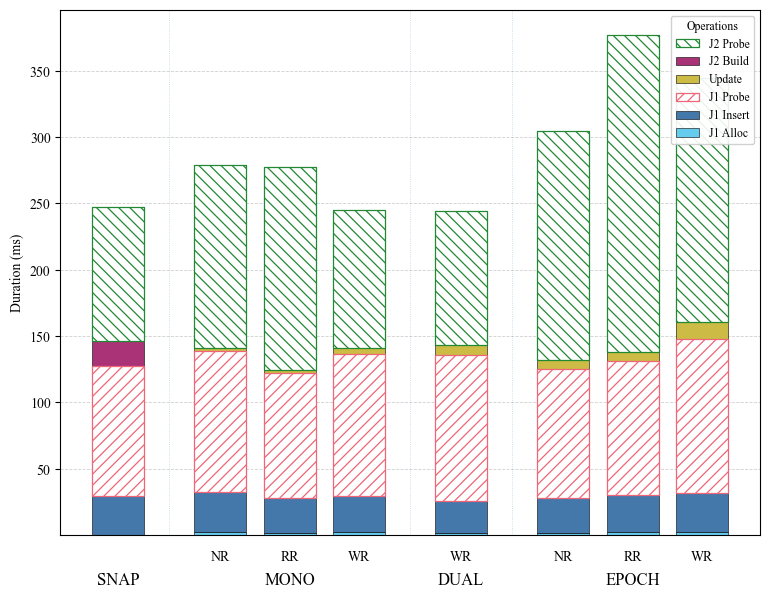

Saved PDF: ./benches/exp4_stock_join/figs/exp4_stock_join_10pct_zipf0.99.pdf


In [116]:
# ── Grouped stacked bar chart ──────────────────────────────────────────────
# Same style as tpch_q14_all_variants.ipynb
# (Paul Tol Bright palette, solid=write, hatch=read)

tol = {
    'blue':   '#4477AA',
    'cyan':   '#66CCEE',
    'green':  '#228833',
    'yellow': '#CCBB44',
    'red':    '#EE6677',
    'purple': '#AA3377',
    'grey':   '#BBBBBB',
}

if {'j1_alloc_ms', 'j1_insert_ms'}.issubset(df.columns):
    phases = [
        ('j1_alloc_ms',   'J1 Alloc',  tol['cyan'],   True),
        ('j1_insert_ms',  'J1 Insert', tol['blue'],   True),
        ('join1_probe_ms','J1 Probe',  tol['red'],    False),
        ('update_ms',     'Update',    tol['yellow'], True),
        ('join2_build_ms','J2 Build',  tol['purple'], True),
        ('join2_probe_ms','J2 Probe',  tol['green'],  False),
    ]
else:
    phases = [
        ('join1_build_ms','J1 Build',  tol['blue'],   True),
        ('join1_probe_ms','J1 Probe',  tol['red'],    False),
        ('update_ms',     'Update',    tol['yellow'], True),
        ('join2_build_ms','J2 Build',  tol['purple'], True),
        ('join2_probe_ms','J2 Probe',  tol['green'],  False),
    ]

hatch_map = {'J1 Probe': '///', 'J2 Probe': '\\\\\\'}

table_order   = ['naive', 'heap', 'chain', 'par']
table_display = {'naive': 'SNAP', 'heap': 'MONO', 'chain': 'DUAL', 'par': 'EPOCH'}
repair_order  = {'naive': [''], 'heap': ['NR','RR','WR'], 'chain': ['WR'], 'par': ['NR','RR','WR']}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif']
plt.rcParams['hatch.linewidth'] = 0.9

bar_w = 0.58
gap   = 0.36
bar_x, minor_labels, major_centers, major_labels, combos = [], [], [], [], []
x = 0.0
for t in table_order:
    subs  = repair_order[t]
    start = x
    for r in subs:
        bar_x.append(x)
        minor_labels.append(r)
        combos.append((t, r))
        x += 0.78
    end = x - 0.78
    major_centers.append((start + end) / 2.0)
    major_labels.append(table_display[t])
    x += gap

fig, ax = plt.subplots(figsize=(7.8, 6.0))
fig.subplots_adjust(bottom=0.22)

for i, (t, r) in enumerate(combos):
    row = df[(df['table'] == t) & (df['repair'] == r)]
    if row.empty:
        continue
    row = row.iloc[0]
    bottom = 0.0
    for (col, lbl, color, is_write) in phases:
        v = float(row.get(col, 0.0))
        if v <= 0:
            continue
        if is_write:
            ax.bar(bar_x[i], v, bottom=bottom, width=bar_w,
                   color=color, edgecolor='black', linewidth=0.4, zorder=2)
        else:
            ax.bar(bar_x[i], v, bottom=bottom, width=bar_w,
                   color='white', edgecolor='black', linewidth=0.4, zorder=2)
            ax.bar(bar_x[i], v, bottom=bottom, width=bar_w,
                   color='none', edgecolor=color, linewidth=0.9,
                   hatch=hatch_map.get(lbl, '///'), zorder=3)
        bottom += v

ax.set_xticks([])
for xi, lab in zip(bar_x, minor_labels):
    ax.text(xi, -0.028, lab, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=10, clip_on=False)
for xc, lab in zip(major_centers, major_labels):
    ax.text(xc, -0.072, lab, ha='center', va='top',
            transform=ax.get_xaxis_transform(), fontsize=12, clip_on=False)

for k in range(1, len(major_centers)):
    prev_end   = max(xx for xx, (tt, _) in zip(bar_x, combos) if tt == table_order[k-1])
    next_start = min(xx for xx, (tt, _) in zip(bar_x, combos) if tt == table_order[k])
    ax.axvline((prev_end + next_start) / 2, linestyle=':', linewidth=0.6, alpha=0.3)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_ylabel('Duration (ms)')

handles, labels_leg = [], []
for (col, lbl, color, is_write) in reversed(phases):
    if is_write:
        patch = Patch(facecolor=color, edgecolor='black', linewidth=0.4)
    else:
        patch = Patch(facecolor='white', edgecolor=color,
                      hatch=hatch_map.get(lbl, '///'), linewidth=0.9)
    handles.append(patch)
    labels_leg.append(lbl)

ax.legend(handles, labels_leg, title='Operations',
          loc='upper right', framealpha=0.9, fontsize=8.5, title_fontsize=8.5)

plt.tight_layout()
out_pdf = EXP4_DIR / 'figs' / f'exp4_stock_join_{pct_label}pct_{DIST}.pdf'
plt.savefig(str(out_pdf), format='pdf')
plt.show()
print('Saved PDF:', out_pdf)

---
## Optional: Update Intensity Sweep (0 → 20%)

Run the cells below to generate the line chart (total latency vs update intensity).
This runs an additional 32 benchmarks (8 configs × 4 extra intensities).

In [117]:
# ── Generate all update files for sweep ────────────────────────────────────
GEN_UPD   = EXP4_DIR / 'generate_stock_updates.py'
SWEEP_PCTS = [0, 5, 10, 15, 20]

for pct in SWEEP_PCTS:
    uf = DATA_DIR / f'stock_updates_w{W}_{pct}pct_{DIST}.tbl'
    if uf.exists():
        print(f'  {pct}% exists.')
        continue
    if pct == 0:
        uf.touch()
        print(f'  0% -> empty file created.')
    else:
        r = subprocess.run(
            [sys.executable, str(GEN_UPD),
             str(STOCK_FILE), str(pct), str(W),
             '--zipf', str(ZIPF_THETA),
             '--output-dir', str(DATA_DIR)],
            check=True, capture_output=True, text=True,
        )
        print(f'  {pct}% ->', r.stdout.strip().split('\n')[-1])

  0% exists.
  5% exists.
  10% exists.
  15% exists.
  20% exists.


In [118]:
# ── Run sweep benchmark ────────────────────────────────────────────────────
SWEEP_CSV = DATA_DIR / f'exp4_w{W}_sweep_{DIST}.csv'

if SWEEP_CSV.exists():
    SWEEP_CSV.unlink()
    print('Removed old sweep CSV')

total_runs = len(SERIES) * len(SWEEP_PCTS)
current    = 0

for pct in SWEEP_PCTS:
    uf = DATA_DIR / f'stock_updates_w{W}_{pct}pct_{DIST}.tbl'
    for (ttype, rmode) in SERIES:
        current += 1
        print(f'[{current}/{total_runs}] table={ttype} repair={rmode} update={pct}%')
        cmd = [
            str(BIN),
            '--stock-file',     str(STOCK_FILE),
            '--orderline-file', str(OL_FILE),
            '--updates-file',   str(uf),
            '--table-type',     ttype,
            '--repair-mode',    rmode,
            '--bucket-num',     str(BUCKET_NUM),
            '--warmup',         str(WARMUP),
            '--repeat',         str(REPEAT),
            '--trim',           str(TRIM),
            '--update-pct',     str(pct),
            '--distribution',   DIST,
            '--output-csv',     str(SWEEP_CSV),
        ]
        r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
        if r.returncode != 0:
            print(f'  FAILED: {r.stderr[:300]}')
        else:
            for line in r.stdout.strip().split('\n'):
                if 'trimmed' in line:
                    print(f'  {line.strip()}')

print(f'\nDone. Results -> {SWEEP_CSV}')

Removed old sweep CSV
[1/40] table=naive repair=nr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[2/40] table=heap repair=nr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[3/40] table=heap repair=rr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[4/40] table=heap repair=wr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[5/40] table=chain repair=wr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[6/40] table=par repair=nr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[7/40] table=par repair=rr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[8/40] table=par repair=wr update=0%
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
[9/40] table=naive repair=nr update=5%
  trimmed me

/var/folders/nn/98fh82v56qz8x_9p3b2fqnym0000gn/T/ipykernel_35481/1073494543.py:35: UserWarning: Glyph 8904 (\N{BOWTIE}) missing from font(s) Times New Roman.
  plt.tight_layout()
/var/folders/nn/98fh82v56qz8x_9p3b2fqnym0000gn/T/ipykernel_35481/1073494543.py:37: UserWarning: Glyph 8904 (\N{BOWTIE}) missing from font(s) Times New Roman.
  plt.savefig(str(out_pdf2), format='pdf')
/var/folders/nn/98fh82v56qz8x_9p3b2fqnym0000gn/T/ipykernel_35481/1073494543.py:37: UserWarning: Glyph 8904 (\N{BOWTIE}) missing from font(s) Times New Roman.
  plt.savefig(str(out_pdf2), format='pdf')
./venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8904 (\N{BOWTIE}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


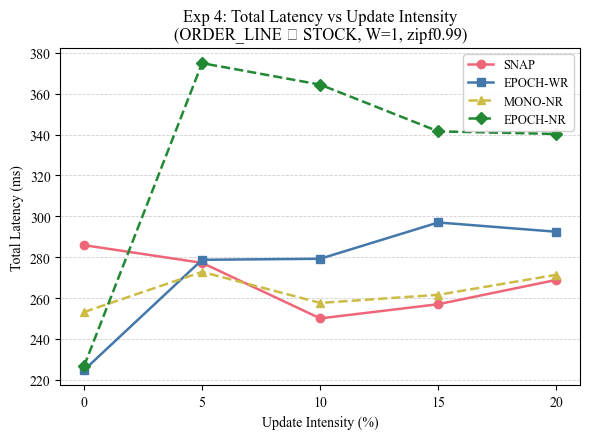

Saved PDF: ./benches/exp4_stock_join/figs/exp4_stock_latency_vs_pct_zipf0.99.pdf


In [119]:
# ── Line chart: total latency vs update intensity ──────────────────────────
dfs = pd.read_csv(SWEEP_CSV)
table_map2  = {'Heap': 'heap', 'Chain': 'chain', 'Par': 'par', 'Naive': 'naive'}
repair_map2 = {'Nr': 'NR', 'Rr': 'RR', 'Wr': 'WR'}
dfs['table']  = dfs['table_type'].map(table_map2).fillna(dfs['table_type'])
dfs['repair'] = dfs['repair_mode'].map(repair_map2).fillna(dfs['repair_mode'])
dfs.loc[dfs['table'] == 'naive', 'repair'] = ''

HIGHLIGHT = [
    ('naive', '',   'SNAP',     '#EE6677', '-',  'o'),
    ('par',   'WR', 'EPOCH-WR', '#4477AA', '-',  's'),
    ('heap',  'NR', 'MONO-NR',  '#CCBB44', '--', '^'),
    ('par',   'NR', 'EPOCH-NR', '#228833', '--', 'D'),
]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'Times', 'Nimbus Roman No9 L', 'DejaVu Serif']

fig2, ax2 = plt.subplots(figsize=(6.0, 4.5))
for (t, r, label, color, ls, marker) in HIGHLIGHT:
    rows = dfs[(dfs['table'] == t) & (dfs['repair'] == r)].sort_values('update_pct')
    if rows.empty:
        continue
    ax2.plot(rows['update_pct'].astype(float), rows['total_ms'],
             label=label, color=color, linestyle=ls, marker=marker,
             linewidth=1.8, markersize=6)

ax2.set_xlabel('Update Intensity (%)')
ax2.set_ylabel('Total Latency (ms)')
ax2.set_title(f'Exp 4: Total Latency vs Update Intensity\n(ORDER_LINE ⋈ STOCK, W={W}, {DIST})')
ax2.set_xticks(SWEEP_PCTS)
ax2.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax2.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
out_pdf2 = EXP4_DIR / 'figs' / f'exp4_stock_latency_vs_pct_{DIST}.pdf'
plt.savefig(str(out_pdf2), format='pdf')
plt.show()
print('Saved PDF:', out_pdf2)